# VGG19 Fine-Tuning — Chest X-Ray Pneumonia
### Anti-Overfitting Version (No SE Block)

| Step | Detail |
|------|--------|
| Dataset | Chest X-Ray Pneumonia (Kaggle) |
| Model | VGG19 (ImageNet pretrained) — fine-tuned, **no SE block** |
| Preprocessing | CLAHE + Gaussian Blur + Resize/Crop + Normalize |
| Anti-overfitting | Downsampling + Dropout + L2 reg + Label Smoothing + Progressive Unfreeze + Early Stopping |
| Variants | Without Augmentation · With Augmentation |
| Metrics | Accuracy, Precision, Recall, F1, Confusion Matrix, Model Size, #Params, Training Time |

## 1. Imports

In [1]:
import os, time, copy, random, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128


## 2. Dataset Download

In [2]:
import kagglehub
dl_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

BASE_DIR = dl_path
for root, dirs, _ in os.walk(dl_path):
    if all(f in dirs for f in ['train', 'test', 'val']):
        BASE_DIR = root
        break

TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
TEST_DIR    = os.path.join(BASE_DIR, 'test')
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
print('Base:', BASE_DIR)

Base: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


## 3. EDA

Class  NORMAL  PNEUMONIA  Total
Split                          
test      234        390    624
train    1341       3875   5216
val         8          8     16
Total    1583       4273   5856


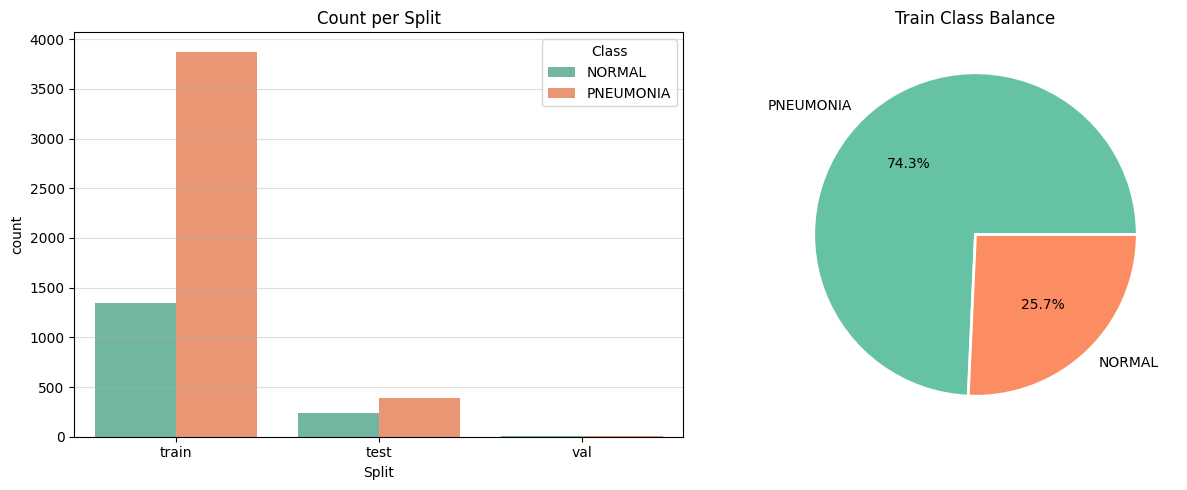

In [3]:
rows = []
for split in ['train', 'test', 'val']:
    for cls in CLASS_NAMES:
        d = os.path.join(BASE_DIR, split, cls)
        if not os.path.exists(d):
            continue
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                rows.append({'Split': split, 'Class': cls,
                             'Path': os.path.join(d, f)})
df = pd.DataFrame(rows)
print(pd.crosstab(df['Split'], df['Class'], margins=True, margins_name='Total'))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x='Split', hue='Class', palette='Set2', ax=ax[0])
ax[0].set_title('Count per Split')
ax[0].grid(axis='y', alpha=0.4)
counts = df[df['Split'] == 'train']['Class'].value_counts()
ax[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
          colors=['#66c2a5', '#fc8d62'],
          wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax[1].set_title('Train Class Balance')
plt.tight_layout()
plt.show()

## 4. Custom Dataset with CLAHE Preprocessing

**All preprocessing techniques applied:**
1. **CLAHE** (Contrast Limited Adaptive Histogram Equalization) on L-channel in LAB color space
2. **Gaussian Blur** (3×3, σ=0.5) for noise reduction
3. **Resize** to 256 → **CenterCrop** to 224 (or RandomCrop with augmentation)
4. **ToTensor** → float32 in [0, 1]
5. **Normalize** with ImageNet mean/std (zero-mean, unit-variance per channel)

In [4]:
class XRayDataset(Dataset):
    """
    Loads chest X-ray images from CLASS_NAME subdirectories.
    Applies CLAHE + Gaussian blur in __getitem__ before the torchvision transform.
    """
    def __init__(self, root_dir, class_names, transform=None):
        self.transform    = transform
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples      = []

        for cls in class_names:
            d = os.path.join(root_dir, cls)
            if not os.path.exists(d):
                continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append(
                        (os.path.join(d, f), self.class_to_idx[cls])
                    )

        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.samples)

    def _apply_clahe(self, img_rgb: np.ndarray) -> Image.Image:
        """CLAHE on L-channel (LAB) + Gaussian blur. Returns PIL Image."""
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = self._clahe.apply(lab[:, :, 0])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        out = cv2.GaussianBlur(out, (3, 3), sigmaX=0.5)
        return Image.fromarray(out)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil_img = self._apply_clahe(img_rgb)   # PIL Image after CLAHE
        if self.transform:
            pil_img = self.transform(pil_img)
        return pil_img, label

    @property
    def targets(self):
        return [s[1] for s in self.samples]

print('XRayDataset defined.')

XRayDataset defined.


## 5. Preprocessing Visualisation
Shows each step: Original → Resize → Crop → CLAHE → Gaussian Blur → Normalized

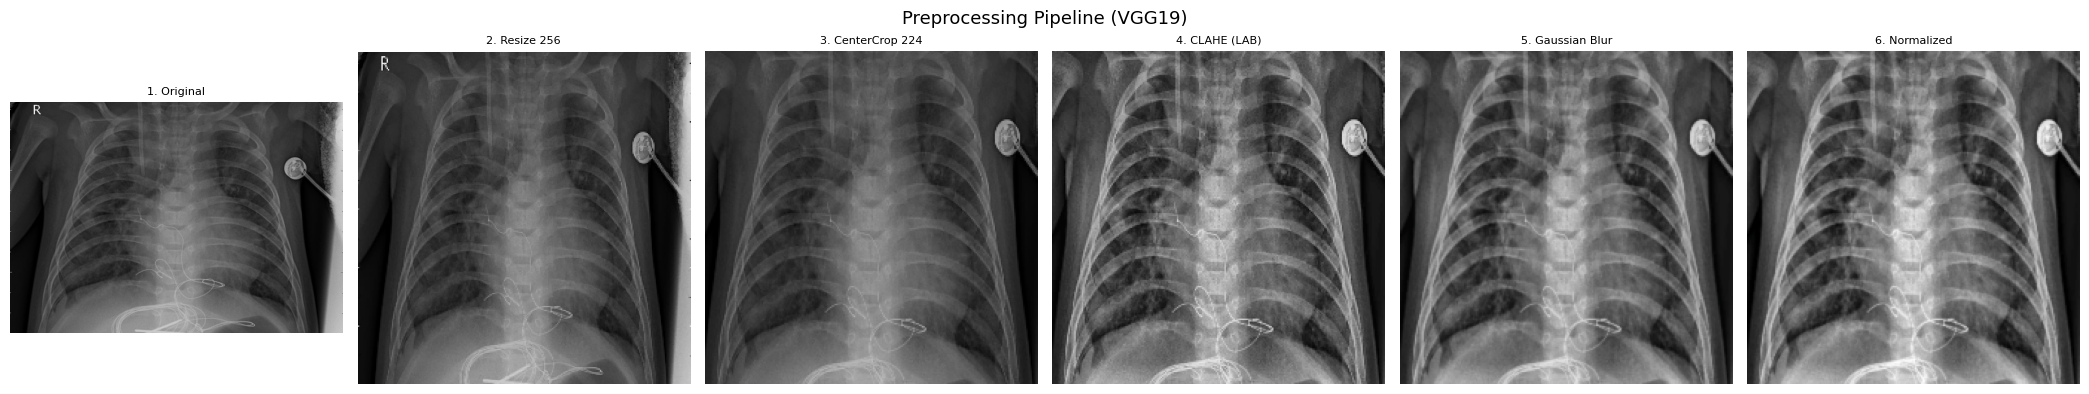

In [5]:
def show_preprocess_steps(img_path):
    bgr      = cv2.imread(img_path)
    original = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized  = cv2.resize(original, (256, 256))
    m        = (256 - 224) // 2
    cropped  = resized[m:m+224, m:m+224]

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab   = cv2.cvtColor(cropped, cv2.COLOR_RGB2LAB)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    clahe_img  = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    blurred    = cv2.GaussianBlur(clahe_img, (3, 3), 0.5)
    norm       = blurred.astype(np.float32) / 255.0
    norm_vis   = ((norm - norm.min()) / (norm.max() - norm.min()) * 255).astype(np.uint8)

    steps = [
        ('1. Original',       original),
        ('2. Resize 256',     resized),
        ('3. CenterCrop 224', cropped),
        ('4. CLAHE (LAB)',    clahe_img),
        ('5. Gaussian Blur',  blurred),
        ('6. Normalized',     norm_vis),
    ]
    fig, axes = plt.subplots(1, 6, figsize=(21, 4))
    fig.suptitle('Preprocessing Pipeline (VGG19)', fontsize=13)
    for ax, (t, im) in zip(axes, steps):
        ax.imshow(im)
        ax.set_title(t, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('preprocess_steps.png', dpi=150, bbox_inches='tight')
    plt.show()

sample_path = df[(df['Split'] == 'train') & (df['Class'] == 'PNEUMONIA')]['Path'].iloc[0]
show_preprocess_steps(sample_path)

## 6. Transforms

**Bug fix inherited from Swin notebook:** `RandomErasing` is placed **after** `ToTensor()` — PIL Images do not have `.shape`.

**Anti-overfitting additions in augmented pipeline:**
- `RandomCrop` with padding (reflect mode)
- `RandomHorizontalFlip`, `RandomVerticalFlip`, `RandomRotation`
- `ColorJitter`, `RandomAdjustSharpness`, `RandomAutocontrast`
- `RandomErasing` ← **after** `ToTensor()`

In [6]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Baseline transform (no augmentation) ─────────────────────────────────────
baseline_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Augmented transform (training only) ──────────────────────────────────────
# RandomErasing is AFTER ToTensor — works on tensors, not PIL images (FIXED)
augmented_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG_SIZE, padding=16, padding_mode='reflect'),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.1),
    T.RandomRotation(degrees=12),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    T.RandomAutocontrast(p=0.3),
    T.ToTensor(),                                      # ← PIL → tensor HERE
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.12),        # ← AFTER ToTensor
                    ratio=(0.3, 3.3), value=0),
])

# ── Test transform ────────────────────────────────────────────────────────────
test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined (RandomErasing correctly placed after ToTensor).')

Transforms defined (RandomErasing correctly placed after ToTensor).


## 7. Augmentation Visualisation

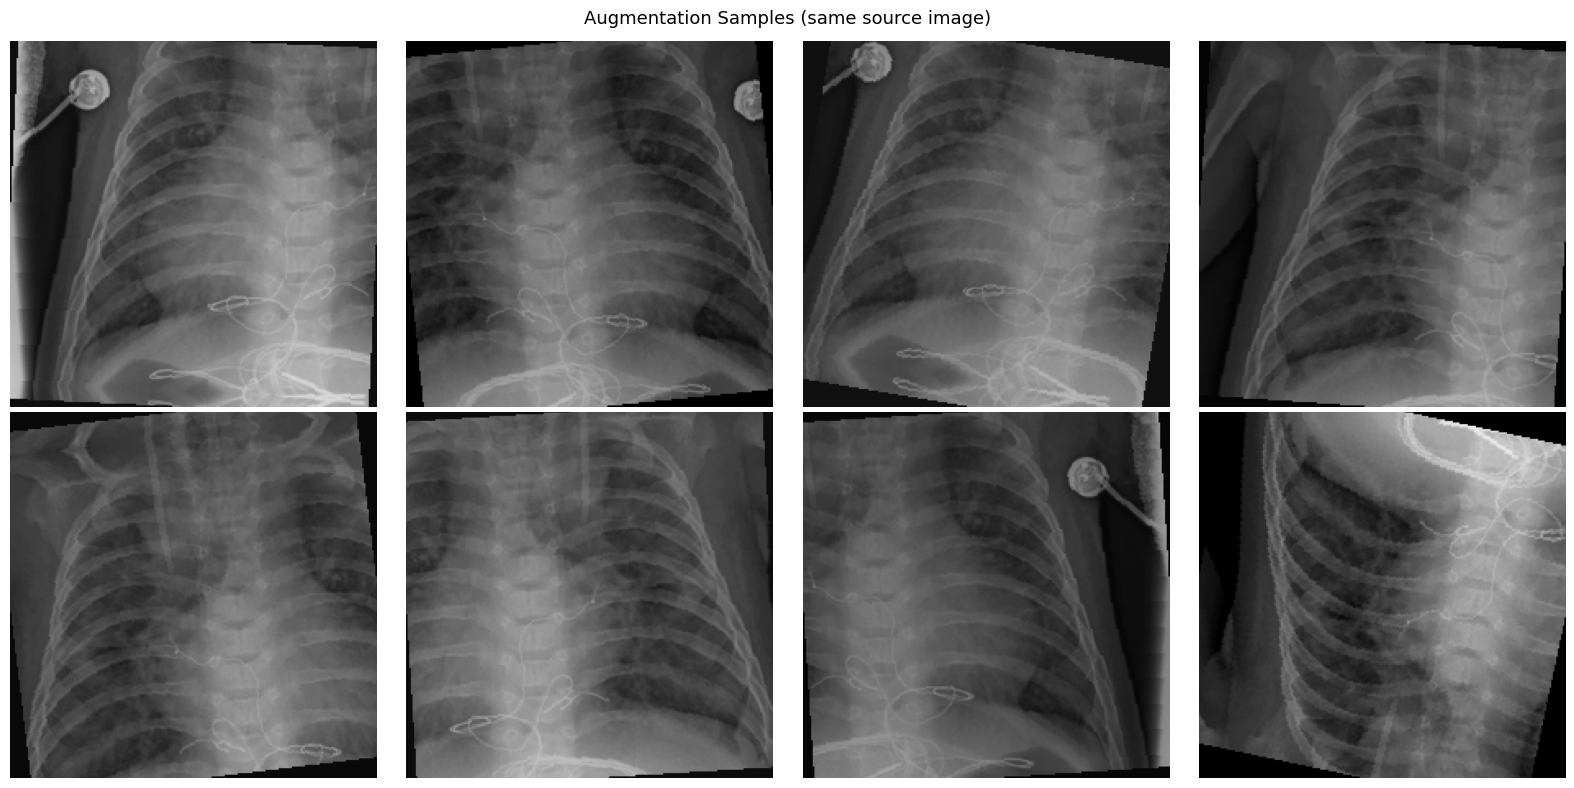

In [7]:
def show_augmentations(img_path, n=8):
    aug_display = T.Compose([
        T.Resize(256),
        T.RandomCrop(IMG_SIZE, padding=16, padding_mode='reflect'),
        T.RandomHorizontalFlip(0.5),
        T.RandomVerticalFlip(0.1),
        T.RandomRotation(12),
        T.ColorJitter(brightness=0.2, contrast=0.2),
    ])
    pil = Image.fromarray(
        cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    )
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 8))
    fig.suptitle('Augmentation Samples (same source image)', fontsize=13)
    for ax in axes.flat:
        ax.imshow(aug_display(pil))
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('augmentation_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_augmentations(sample_path)

## 8. Downsampling — Anti-Overfitting / Class Balance

**Why downsampling?**
- Original: NORMAL=1341, PNEUMONIA=3875 (2.9× imbalance)
- Random undersampling of PNEUMONIA to match NORMAL count
- Reduces memorisation risk + speeds up epochs

In [8]:
def build_balanced_subset(dataset, seed=SEED):
    """
    Random undersampling: reduces the majority class to match minority.
    Returns a Subset with balanced class counts.
    """
    targets = dataset.targets
    indices_by_class = {}
    for idx, lbl in enumerate(targets):
        indices_by_class.setdefault(lbl, []).append(idx)

    min_count = min(len(v) for v in indices_by_class.values())
    rng = random.Random(seed)

    balanced_indices = []
    for cls, idxs in indices_by_class.items():
        sampled = rng.sample(idxs, min_count)
        balanced_indices.extend(sampled)

    rng.shuffle(balanced_indices)
    counts = Counter([targets[i] for i in balanced_indices])
    print(f'  Balanced dataset: {dict(counts)} (total={len(balanced_indices)})')
    return Subset(dataset, balanced_indices)


# ── Build datasets ────────────────────────────────────────────────────────────
full_train_base = XRayDataset(TRAIN_DIR, CLASS_NAMES, transform=baseline_transform)
full_train_aug  = XRayDataset(TRAIN_DIR, CLASS_NAMES, transform=augmented_transform)
test_ds         = XRayDataset(TEST_DIR,  CLASS_NAMES, transform=test_transform)

print(f'Full train: {len(full_train_base)} | Test: {len(test_ds)}')
print(f'Train class dist: {Counter(full_train_base.targets)}')

print('\nDownsampling...')
print('Baseline:');  train_base_balanced = build_balanced_subset(full_train_base)
print('Augmented:'); train_aug_balanced  = build_balanced_subset(full_train_aug)


def make_loader(dataset, shuffle=True):
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=4, pin_memory=True, persistent_workers=True)

train_loader_base = make_loader(train_base_balanced, shuffle=True)
train_loader_aug  = make_loader(train_aug_balanced,  shuffle=True)
test_loader       = make_loader(test_ds, shuffle=False)

print(f'\nLoaders ready.')
print(f'  Train base batches: {len(train_loader_base)}')
print(f'  Train aug  batches: {len(train_loader_aug)}')
print(f'  Test  batches     : {len(test_loader)}')

Full train: 5216 | Test: 624
Train class dist: Counter({1: 3875, 0: 1341})

Downsampling...
Baseline:
  Balanced dataset: {1: 1341, 0: 1341} (total=2682)
Augmented:
  Balanced dataset: {1: 1341, 0: 1341} (total=2682)

Loaders ready.
  Train base batches: 84
  Train aug  batches: 84
  Test  batches     : 20


## 9. VGG19 Model — Fine-Tuning (No SE Block)

**Architecture:**
```
VGG19 backbone (pretrained ImageNet)
  → features: 13 conv layers + 5 MaxPool  [frozen initially]
  → AdaptiveAvgPool2d(7×7)
  → Custom Classifier Head:
      Linear(25088 → 4096) → ReLU → Dropout(0.5)
      Linear(4096  → 1024) → ReLU → Dropout(0.5)
      Linear(1024  → num_classes)
```

**Anti-overfitting design:**
- Backbone **frozen** for first `freeze_epochs`, then **progressively unfrozen** with lower LR
- **Dropout 0.5** in classifier head
- **L2 weight decay** via AdamW
- **Label smoothing 0.1** in CrossEntropyLoss
- **Cosine Annealing LR** scheduler
- **Early Stopping** on validation loss

In [9]:
def build_vgg19(num_classes=2, dropout=0.5):
    """
    Fine-tune VGG19 with a custom head.
    Returns model with freeze_backbone / unfreeze_backbone methods.
    """
    class VGG19FineTune(nn.Module):
        def __init__(self):
            super().__init__()
            base = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
            self.features  = base.features          # conv layers
            self.avgpool   = base.avgpool            # AdaptiveAvgPool2d(7,7)

            # VGG19 flattened feature size = 512*7*7 = 25088
            in_features = 512 * 7 * 7
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(in_features, 4096),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout),
                nn.Linear(4096, 1024),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout),
                nn.Linear(1024, num_classes),
            )
            # Initialise custom head
            for m in self.classifier.modules():
                if isinstance(m, nn.Linear):
                    nn.init.trunc_normal_(m.weight, std=0.02)
                    nn.init.zeros_(m.bias)

        def forward(self, x):
            x = self.features(x)    # (B, 512, 7, 7)
            x = self.avgpool(x)     # (B, 512, 7, 7)
            x = self.classifier(x)  # (B, num_classes)
            return x

        def freeze_backbone(self):
            for p in self.features.parameters():
                p.requires_grad = False

        def unfreeze_backbone(self):
            for p in self.features.parameters():
                p.requires_grad = True

    model = VGG19FineTune()
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Total params: {total/1e6:.2f}M | Trainable: {trainable/1e6:.2f}M')
    return model


# Quick sanity check
print('Building VGG19 (fresh, all trainable):')
_m = build_vgg19()
dummy = torch.zeros(2, 3, 224, 224)
with torch.no_grad():
    out = _m(dummy)
print(f'  Forward pass OK — output shape: {tuple(out.shape)}')
del _m, dummy, out

Building VGG19 (fresh, all trainable):
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 216MB/s] 


  Total params: 126.99M | Trainable: 126.99M
  Forward pass OK — output shape: (2, 2)


## 10. Training Loop with Progressive Unfreeze + Early Stopping

In [10]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


def train_variant(label, train_loader,
                  epochs=15, lr=1e-4, patience=5,
                  freeze_epochs=3, weight_decay=1e-3,
                  label_smoothing=0.1, dropout=0.5):
    """
    Full training pipeline for one VGG19 variant.

    Progressive unfreeze strategy
    ─────────────────────────────
    Epochs 1..freeze_epochs   : backbone frozen  → only classifier trains
    Epochs freeze_epochs+1..N : backbone unfrozen → backbone lr/10, head lr=lr
    """
    print('=' * 60)
    print(f'  {label}')
    print('=' * 60)

    model = build_vgg19(num_classes=2, dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler    = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')

    # Phase 1: freeze backbone
    model.freeze_backbone()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 0.01
    )

    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc': [],  'val_acc': [],
                  'epoch_times': []}
    best_acc   = 0.0
    best_wts   = None
    no_improve = 0
    t_total    = time.time()

    for epoch in range(1, epochs + 1):

        # Progressive unfreeze
        if epoch == freeze_epochs + 1:
            print(f'  → Epoch {epoch}: Unfreezing backbone (backbone lr={lr/10:.0e})')
            model.unfreeze_backbone()
            optimizer = optim.AdamW([
                {'params': model.features.parameters(),    'lr': lr / 10},
                {'params': model.classifier.parameters(),  'lr': lr},
            ], weight_decay=weight_decay)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - freeze_epochs, eta_min=lr * 0.01
            )

        t_ep = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        ep_t = time.time() - t_ep

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['epoch_times'].append(ep_t)

        gap = tr_acc - vl_acc
        print(f'  Epoch {epoch:02d}/{epochs} '
              f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} '
              f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} '
              f'gap={gap:+.3f} [{ep_t:.1f}s]')

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_wts   = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

    total_t = time.time() - t_total
    history['total_time'] = round(total_t, 1)
    history['avg_epoch']  = round(np.mean(history['epoch_times']), 1)
    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), f'/kaggle/working/{label}.pth')
    print(f'  Best val acc: {best_acc:.4f} | Total: {total_t:.1f}s')
    return model, history


print('Training functions ready.')

Training functions ready.


## 11. Evaluation & Plotting Utilities

In [11]:
@torch.no_grad()
def evaluate_model(model, loader, label):
    model.eval()
    all_preds, all_true = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(labels.numpy())

    acc  = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='weighted', zero_division=0)
    rec  = recall_score(all_true, all_preds,    average='weighted', zero_division=0)
    f1   = f1_score(all_true, all_preds,        average='weighted', zero_division=0)
    cm   = confusion_matrix(all_true, all_preds)

    # Model size
    tmp = f'/tmp/{label}.pth'
    torch.save(model.state_dict(), tmp)
    size_mb  = round(os.path.getsize(tmp) / 1024**2, 2)
    total_p  = sum(p.numel() for p in model.parameters())
    train_p  = sum(p.numel() for p in model.parameters() if p.requires_grad)

    metrics = {
        'Accuracy'             : round(acc,  4),
        'Precision'            : round(prec, 4),
        'Recall'               : round(rec,  4),
        'F1 Score'             : round(f1,   4),
        'Confusion Matrix'     : cm,
        'Model Size (MB)'      : size_mb,
        'Total Params (M)'     : round(total_p / 1e6, 2),
        'Trainable Params (M)' : round(train_p / 1e6, 2),
    }
    print(f'\n=== {label} ===')
    for k, v in metrics.items():
        if k != 'Confusion Matrix':
            print(f'  {k}: {v}')
    print()
    print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))
    return metrics


def plot_history(history, label):
    eps    = range(1, len(history['train_loss']) + 1)
    tr_acc = np.array(history['train_acc'])
    vl_acc = np.array(history['val_acc'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {label}', fontsize=13)

    axes[0].plot(eps, history['train_loss'], 'b-o', ms=4, label='Train Loss')
    axes[0].plot(eps, history['val_loss'],   'r-s', ms=4, label='Val Loss')
    axes[0].set_title('Loss vs Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.4)

    axes[1].plot(eps, tr_acc, 'b-o', ms=4, label='Train Acc')
    axes[1].plot(eps, vl_acc, 'r-s', ms=4, label='Val Acc')
    axes[1].fill_between(eps, vl_acc, tr_acc,
                          where=(tr_acc > vl_acc),
                          alpha=0.15, color='red', label='Overfitting gap')
    axes[1].set_title('Accuracy vs Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'history_{label.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_cm(cm, label):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {label}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'cm_{label.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Evaluation utilities ready.')

Evaluation utilities ready.


## 12. Variant 1 — VGG19 Without Augmentation (Baseline)
Preprocessing: CLAHE → Gaussian Blur → Resize(256) → CenterCrop(224) → Normalize

In [12]:
model_base, hist_base = train_variant(
    label='VGG19_NoAug',
    train_loader=train_loader_base,
    epochs=15,
    lr=1e-4,
    patience=5,
    freeze_epochs=3,
    weight_decay=1e-3,
    label_smoothing=0.1,
    dropout=0.5
)

  VGG19_NoAug
  Total params: 126.99M | Trainable: 126.99M
  Epoch 01/15 tr_loss=0.5212 tr_acc=0.8811 vl_loss=0.4006 vl_acc=0.8670 gap=+0.014 [96.9s]
  Epoch 02/15 tr_loss=0.3171 tr_acc=0.9478 vl_loss=0.5769 vl_acc=0.7740 gap=+0.174 [95.5s]
  Epoch 03/15 tr_loss=0.2887 tr_acc=0.9657 vl_loss=0.4685 vl_acc=0.8253 gap=+0.140 [94.5s]
  → Epoch 4: Unfreezing backbone (backbone lr=1e-05)
  Epoch 04/15 tr_loss=0.2686 tr_acc=0.9720 vl_loss=0.4355 vl_acc=0.8558 gap=+0.116 [97.5s]
  Epoch 05/15 tr_loss=0.2379 tr_acc=0.9914 vl_loss=0.4807 vl_acc=0.8333 gap=+0.158 [98.7s]
  Epoch 06/15 tr_loss=0.2220 tr_acc=0.9974 vl_loss=0.4740 vl_acc=0.8462 gap=+0.151 [97.9s]
  Early stopping at epoch 6
  Best val acc: 0.8670 | Total: 581.1s


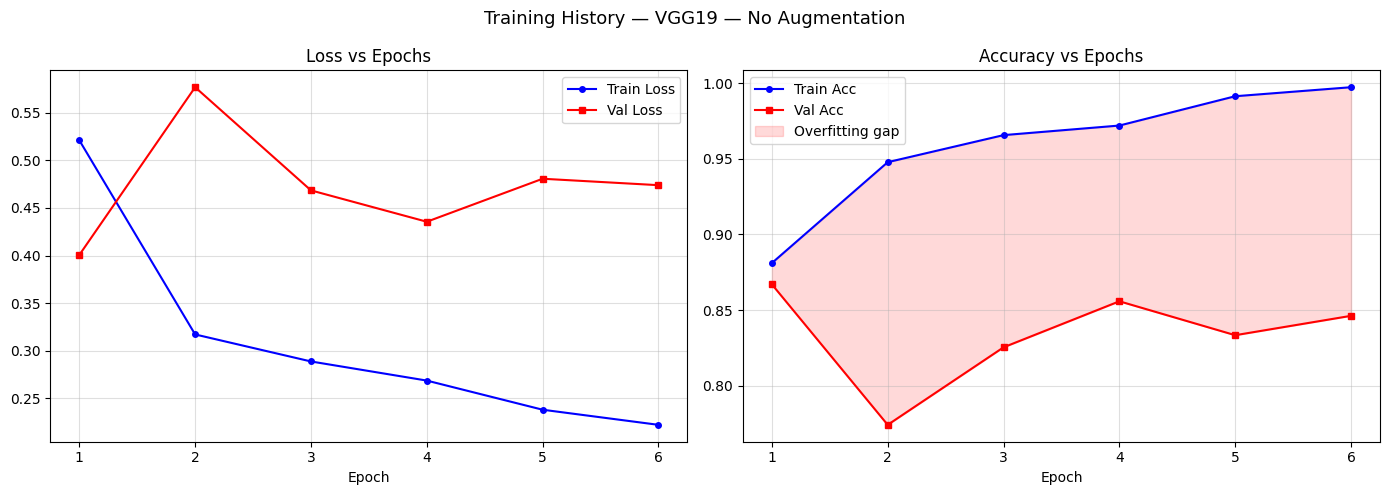


=== VGG19: No Augmentation ===
  Accuracy: 0.867
  Precision: 0.8684
  Recall: 0.867
  F1 Score: 0.8643
  Model Size (MB): 484.43
  Total Params (M): 126.99
  Trainable Params (M): 126.99

              precision    recall  f1-score   support

      NORMAL       0.88      0.74      0.81       234
   PNEUMONIA       0.86      0.94      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.87      0.86       624



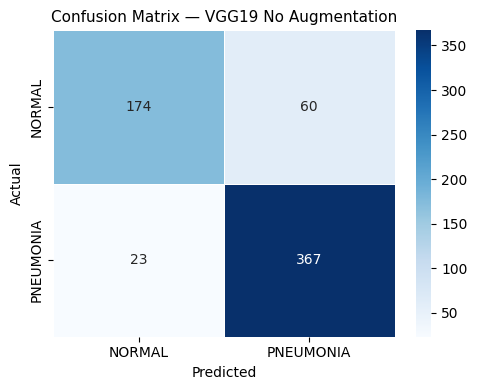

In [13]:
plot_history(hist_base, 'VGG19 — No Augmentation')

m_base = evaluate_model(model_base, test_loader, 'VGG19: No Augmentation')
m_base['Total Time (s)'] = hist_base['total_time']
m_base['Avg Epoch (s)']  = hist_base['avg_epoch']

plot_cm(m_base['Confusion Matrix'], 'VGG19 No Augmentation')

## 13. Variant 2 — VGG19 With Augmentation
Same preprocessing + RandomCrop, Flip, Rotation, ColorJitter, RandomErasing (after ToTensor)

In [14]:
model_aug, hist_aug = train_variant(
    label='VGG19_Aug',
    train_loader=train_loader_aug,
    epochs=15,
    lr=1e-4,
    patience=5,
    freeze_epochs=3,
    weight_decay=1e-3,
    label_smoothing=0.1,
    dropout=0.5
)

  VGG19_Aug
  Total params: 126.99M | Trainable: 126.99M
  Epoch 01/15 tr_loss=0.6762 tr_acc=0.7479 vl_loss=0.5666 vl_acc=0.7740 gap=-0.026 [100.1s]
  Epoch 02/15 tr_loss=0.4946 tr_acc=0.8333 vl_loss=0.5386 vl_acc=0.7788 gap=+0.054 [99.8s]
  Epoch 03/15 tr_loss=0.4415 tr_acc=0.8617 vl_loss=0.4177 vl_acc=0.8638 gap=-0.002 [100.9s]
  → Epoch 4: Unfreezing backbone (backbone lr=1e-05)
  Epoch 04/15 tr_loss=0.3992 tr_acc=0.8855 vl_loss=0.4042 vl_acc=0.8862 gap=-0.001 [102.7s]
  Epoch 05/15 tr_loss=0.3346 tr_acc=0.9273 vl_loss=0.3864 vl_acc=0.8926 gap=+0.035 [103.1s]
  Epoch 06/15 tr_loss=0.3176 tr_acc=0.9355 vl_loss=0.3836 vl_acc=0.8910 gap=+0.044 [104.7s]
  Epoch 07/15 tr_loss=0.3054 tr_acc=0.9430 vl_loss=0.4040 vl_acc=0.8798 gap=+0.063 [102.8s]
  Epoch 08/15 tr_loss=0.2962 tr_acc=0.9515 vl_loss=0.3666 vl_acc=0.9103 gap=+0.041 [102.4s]
  Epoch 09/15 tr_loss=0.2810 tr_acc=0.9582 vl_loss=0.3857 vl_acc=0.8910 gap=+0.067 [103.0s]
  Epoch 10/15 tr_loss=0.2793 tr_acc=0.9560 vl_loss=0.4103 vl_ac

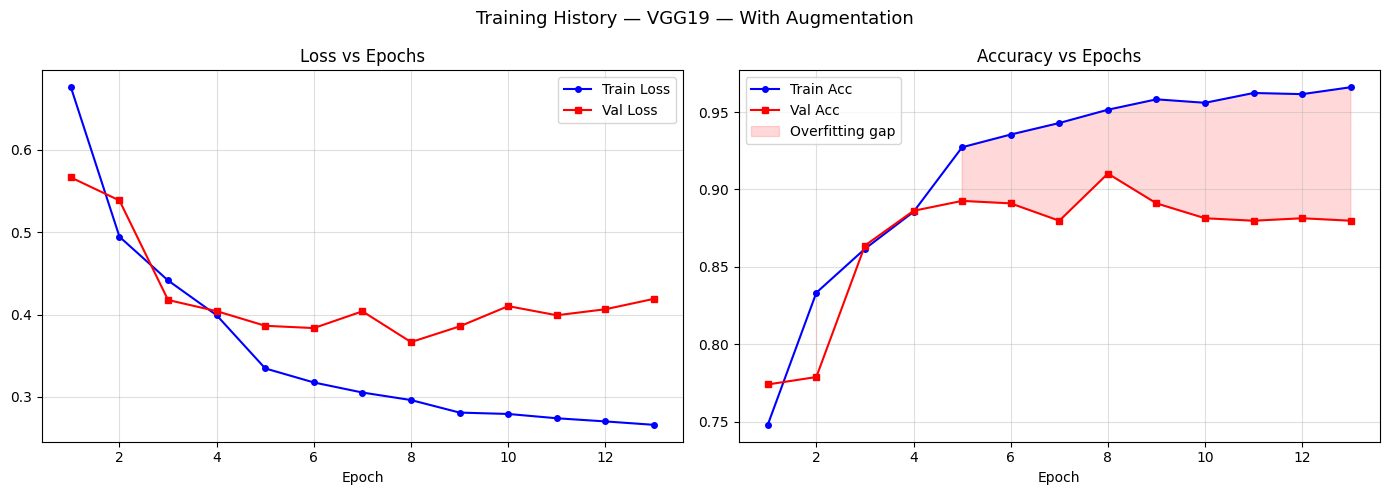


=== VGG19: With Augmentation ===
  Accuracy: 0.9103
  Precision: 0.9121
  Recall: 0.9103
  F1 Score: 0.9088
  Model Size (MB): 484.43
  Total Params (M): 126.99
  Trainable Params (M): 126.99

              precision    recall  f1-score   support

      NORMAL       0.94      0.82      0.87       234
   PNEUMONIA       0.90      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



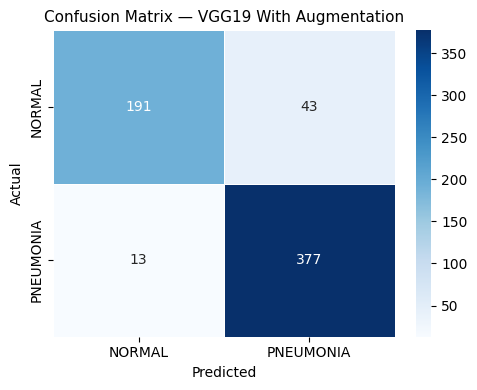

In [15]:
plot_history(hist_aug, 'VGG19 — With Augmentation')

m_aug = evaluate_model(model_aug, test_loader, 'VGG19: With Augmentation')
m_aug['Total Time (s)'] = hist_aug['total_time']
m_aug['Avg Epoch (s)']  = hist_aug['avg_epoch']

plot_cm(m_aug['Confusion Matrix'], 'VGG19 With Augmentation')

## 14. Results Table

In [17]:
variants = [
    ('No Aug',  m_base),
    ('With Aug', m_aug),
]

rows = []
for v, m in variants:
    rows.append({
        'Variant'   : v,
        'Accuracy'  : m['Accuracy'],
        'Precision' : m['Precision'],
        'Recall'    : m['Recall'],
        'F1 Score'  : m['F1 Score'],
        'Size(MB)'  : m['Model Size (MB)'],
        'Params(M)' : m['Total Params (M)'],
        'Time(s)'   : m['Total Time (s)'],
        'Avg Ep(s)' : m['Avg Epoch (s)'],
    })

res_df = pd.DataFrame(rows)
print('\n========= VGG19 RESULTS =========')
print(res_df.to_string(index=False))
res_df.to_csv('/kaggle/working/vgg19_results.csv', index=False)


========= VGG19 RESULTS =========
 Variant  Accuracy  Precision  Recall  F1 Score  Size(MB)  Params(M)  Time(s)  Avg Ep(s)
  No Aug    0.8670     0.8684  0.8670    0.8643    484.43     126.99    581.1       96.8
With Aug    0.9103     0.9121  0.9103    0.9088    484.43     126.99   1327.2      102.1


## 15. Comparison Plots

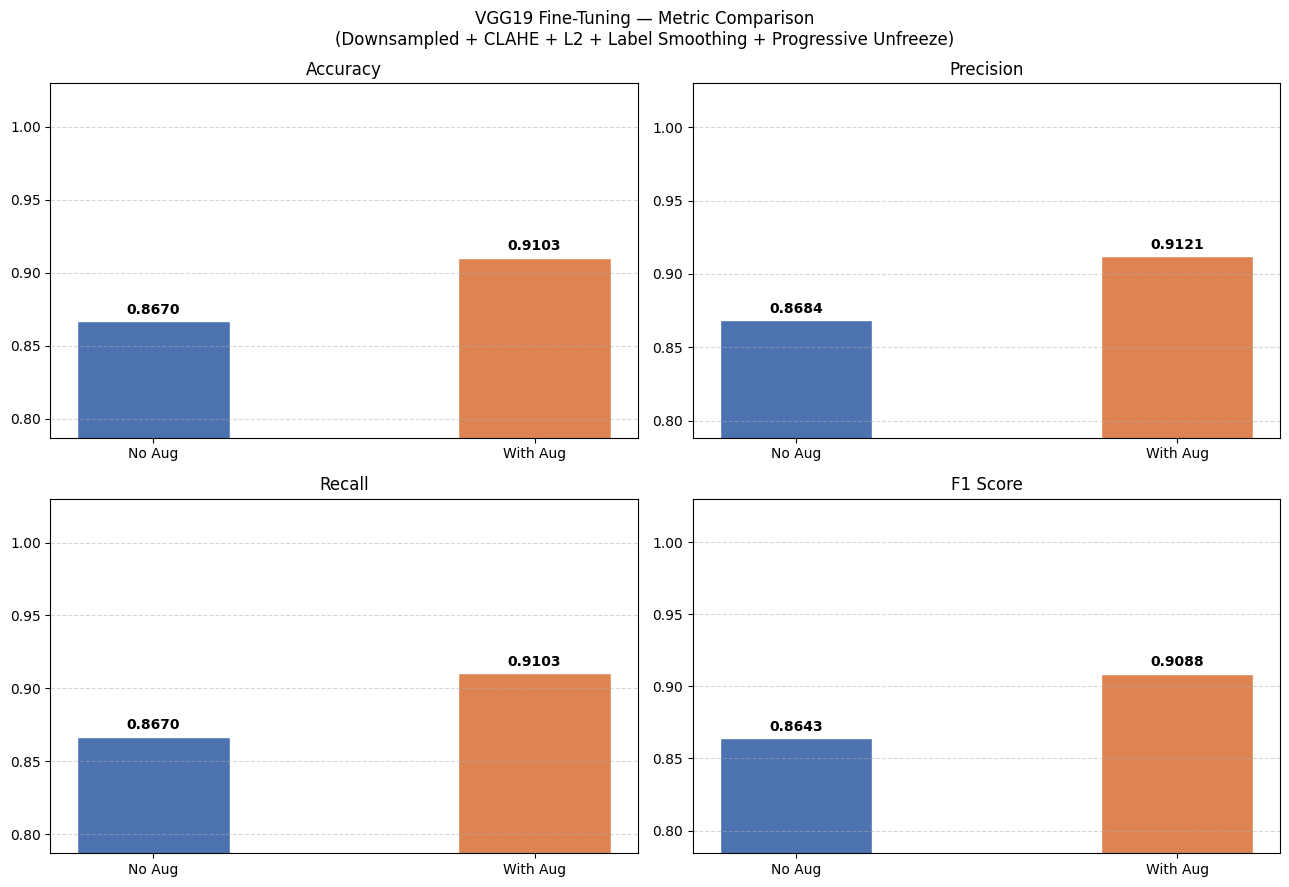

In [18]:
# ── Bar charts: Accuracy / Precision / Recall / F1 ───────────────────────────
colors = ['#4C72B0', '#DD8452']
short  = ['No Aug', 'With Aug']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('VGG19 Fine-Tuning — Metric Comparison\n'
             '(Downsampled + CLAHE + L2 + Label Smoothing + Progressive Unfreeze)',
             fontsize=12)

for ax, metric in zip(axes.flat, ['Accuracy', 'Precision', 'Recall', 'F1 Score']):
    vals = res_df[metric].values
    bars = ax.bar(short, vals, color=colors, edgecolor='white', width=0.4)
    ax.set_title(metric, fontsize=12)
    lo = max(0, vals.min() - 0.08)
    ax.set_ylim(lo, 1.03)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('vgg19_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

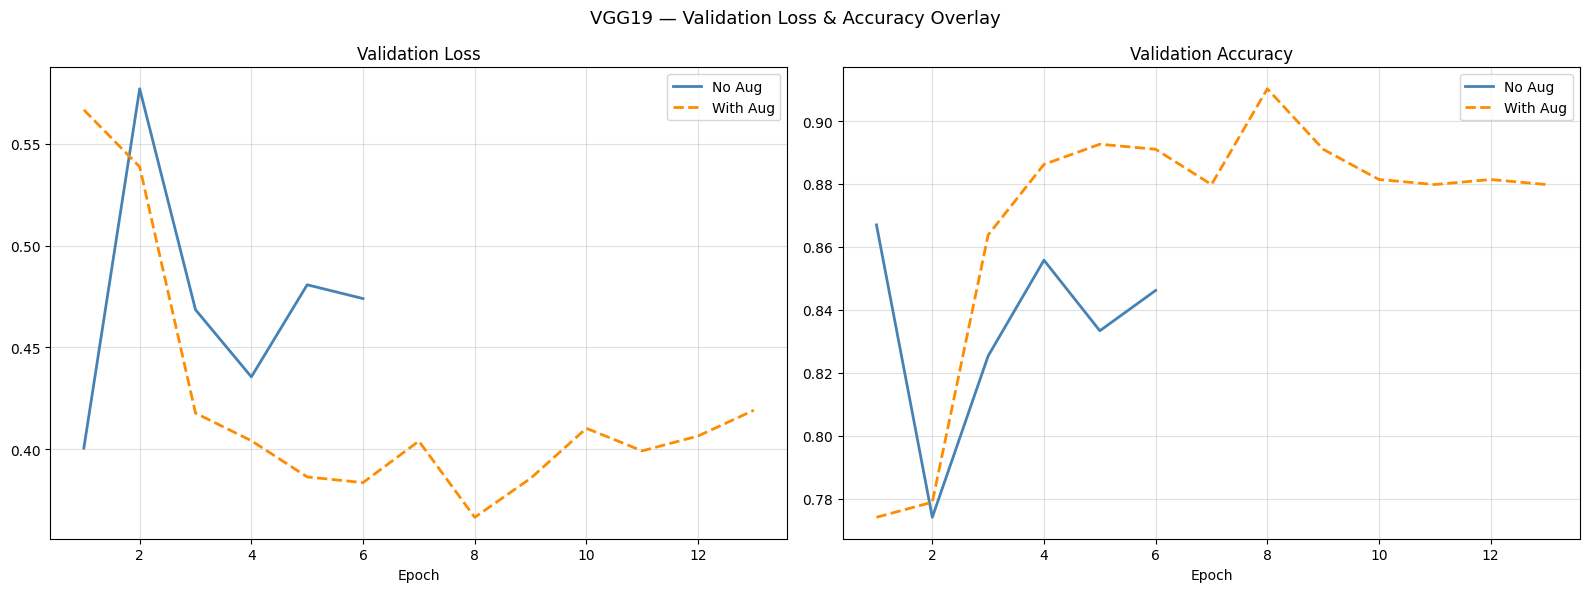

In [19]:
# ── Overlay: Val Loss & Val Accuracy for both variants ───────────────────────
histories   = [hist_base, hist_aug]
var_labels  = ['No Aug', 'With Aug']
styles      = [('steelblue', '-'), ('darkorange', '--')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VGG19 — Validation Loss & Accuracy Overlay', fontsize=13)

for h, lbl, (col, ls) in zip(histories, var_labels, styles):
    ep = range(1, len(h['train_loss']) + 1)
    axes[0].plot(ep, h['val_loss'], color=col, ls=ls, lw=2, label=lbl)
    axes[1].plot(ep, h['val_acc'],  color=col, ls=ls, lw=2, label=lbl)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.4)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('vgg19_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

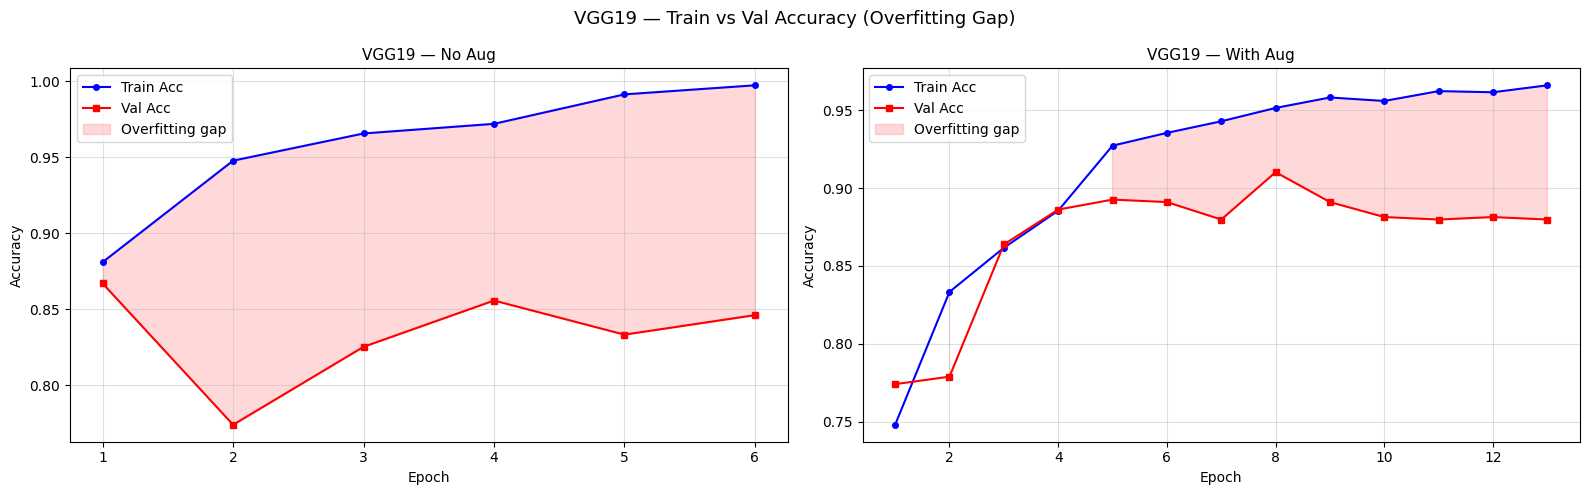

In [20]:
# ── Overfitting gap per variant ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('VGG19 — Train vs Val Accuracy (Overfitting Gap)', fontsize=13)

for ax, h, lbl in zip(axes, histories, var_labels):
    ep  = list(range(1, len(h['train_acc']) + 1))
    tr  = np.array(h['train_acc'])
    vl  = np.array(h['val_acc'])
    ax.plot(ep, tr, 'b-o', ms=4, label='Train Acc')
    ax.plot(ep, vl, 'r-s', ms=4, label='Val Acc')
    ax.fill_between(ep, vl, tr, where=(tr > vl),
                    alpha=0.15, color='red', label='Overfitting gap')
    ax.set_title(f'VGG19 — {lbl}', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('vgg19_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

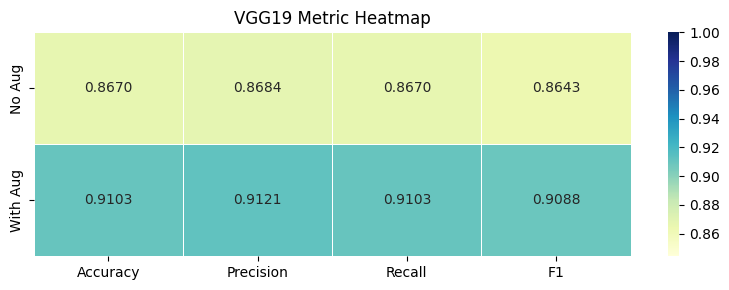

In [21]:
# ── Heatmap ───────────────────────────────────────────────────────────────────
heat = res_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].values
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=['Accuracy', 'Precision', 'Recall', 'F1'],
            yticklabels=['No Aug', 'With Aug'],
            vmin=heat.min() - 0.02, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title('VGG19 Metric Heatmap', fontsize=12)
plt.tight_layout()
plt.savefig('vgg19_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Final Summary

In [22]:
print('=' * 65)
print('FINAL VGG19 SUMMARY')
print('=' * 65)
print(res_df[['Variant', 'Accuracy', 'Precision', 'Recall',
              'F1 Score', 'Params(M)', 'Size(MB)',
              'Time(s)', 'Avg Ep(s)']].to_string(index=False))

best = res_df.loc[res_df['Accuracy'].idxmax()]
print(f'\n✅  Best : VGG19 — {best["Variant"]}')
print(f'    Accuracy : {best["Accuracy"]}')
print(f'    F1       : {best["F1 Score"]}')

delta = res_df.loc[1, 'Accuracy'] - res_df.loc[0, 'Accuracy']
print(f'\nAugmentation effect on Accuracy: {delta:+.4f}')

FINAL VGG19 SUMMARY
 Variant  Accuracy  Precision  Recall  F1 Score  Params(M)  Size(MB)  Time(s)  Avg Ep(s)
  No Aug    0.8670     0.8684  0.8670    0.8643     126.99    484.43    581.1       96.8
With Aug    0.9103     0.9121  0.9103    0.9088     126.99    484.43   1327.2      102.1

✅  Best : VGG19 — With Aug
    Accuracy : 0.9103
    F1       : 0.9088

Augmentation effect on Accuracy: +0.0433
